In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# load dataset 
# file_path = "proquest_with_ocr_scores.csv"
file_path = "/Users/carmand/Desktop/RS/data/proquest_meta_with_ocr_scores.csv"
df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,DocId,category,category_clean,Date,Title,Source,Text,ocr_score,language
0,1,1420657823,"Feature, Article",Article / Feature,19140615,Boxer Indemnity Remission,Peking Daily News,Boxer Indemnity Remission -Mr ...,0.9,en
1,2,1371519349,"Letter to the Editor, Correspondence",Letter / Correspondence,19480417,US-Educated,The China Weekly Review,US-Educated To The Editor ...,1.0,en
2,3,1760438849,"Article, Feature",Article / Feature,19390727,BOXER SCHOLARSHIP,South China Morning Post Ltd.,BOXER SCHOLARSHIP The 71h annu...,1.0,en
3,4,1760466297,"Article, Feature",Article / Feature,19391121,BOXER SCHOLARSHIP,South China Morning Post Ltd.,BOXER SCHOLARSHIP Chunekine No...,1.0,en
4,5,1760024364,"Article, Feature",Article / Feature,19380621,BOXER SCHOLARSHIP,South China Morning Post Ltd.,BOXER SCHOLARSHIP Centres for ...,1.0,en


In [9]:
# Basic cleaning

# Convert date column to datetime
# Original format appears to be YYYYMMDD

df['Date'] = pd.to_datetime(df['Date'].astype(str), format='%Y%m%d', errors='coerce')

# Extract year and decade

df['year'] = df['Date'].dt.year
df['decade'] = (df['year'] // 10) * 10

# Remove rows with missing OCR scores

df = df[df['ocr_score'].notna()]

In [10]:
# GENERAL SUMMARY STATISTICS
# ---------------------------------------------

print("\n==============================")
print("GENERAL OCR SCORE STATISTICS")
print("==============================\n")

print(df['ocr_score'].describe())

print("\nMedian OCR score:", df['ocr_score'].median())
print("\nVariance:", df['ocr_score'].var())
print("\nSkewness:", df['ocr_score'].skew())



GENERAL OCR SCORE STATISTICS

count    4750.000000
mean        0.974989
std         0.047575
min         0.600000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: ocr_score, dtype: float64

Median OCR score: 1.0

Variance: 0.0022633711252229866

Skewness: -1.7630487133852286


In [34]:
# SUMMARY BY LANGUAGE
# ---------------------------------------------

print("\n==============================")
print("OCR SCORE BY LANGUAGE")
print("==============================\n")

language_stats = (
    df.groupby('language')['ocr_score']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .sort_values(by='mean', ascending=False)
)

print(language_stats)


OCR SCORE BY LANGUAGE

          count      mean  median       std  min  max
language                                             
en         4598  0.977055     1.0  0.045482  0.6  1.0
fr           14  0.692857     0.7  0.073005  0.6  0.8
de            4  0.650000     0.6  0.100000  0.6  0.8
lb          134  0.625373     0.6  0.092327  0.4  0.8


In [11]:
# SUMMARY BY CATEGORY
# ---------------------------------------------

print("\n==============================")
print("OCR SCORE BY CATEGORY")
print("==============================\n")

category_stats = (
    df.groupby('category_clean')['ocr_score']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .sort_values(by='mean', ascending=False)
)

print(category_stats)


OCR SCORE BY CATEGORY

                          count      mean  median       std  min  max
category_clean                                                       
Review                       48  1.000000    1.00  0.000000  1.0  1.0
Letter / Correspondence     176  0.996591    1.00  0.018198  0.9  1.0
Editorial / Commentary      225  0.996000    1.00  0.019640  0.9  1.0
Personal Notices              7  0.985714    1.00  0.037796  0.9  1.0
Article / Feature          3114  0.985549    1.00  0.036774  0.7  1.0
Image/Photograph             27  0.959259    1.00  0.050071  0.9  1.0
Front Page/Cover Story      164  0.958537    1.00  0.053011  0.8  1.0
General Information          18  0.955556    1.00  0.061570  0.8  1.0
Front Matter                 22  0.945455    0.95  0.059580  0.8  1.0
Advertisement               433  0.942494    1.00  0.064516  0.6  1.0
Classified Advertisement    516  0.927519    0.90  0.056932  0.8  1.0


In [12]:
# SUMMARY BY NEWSPAPER / SOURCE
# ---------------------------------------------

print("\n==============================")
print("OCR SCORE BY SOURCE")
print("==============================\n")

source_stats = (
    df.groupby('Source')['ocr_score']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .sort_values(by='mean', ascending=False)
)

print(source_stats)


OCR SCORE BY SOURCE

                               count      mean  median       std  min  max
Source                                                                    
The Chinese Repository             2  1.000000     1.0  0.000000  1.0  1.0
The Peking Leader                 23  1.000000     1.0  0.000000  1.0  1.0
The Chinese Recorder             147  0.998639     1.0  0.011624  0.9  1.0
The China Weekly Review          921  0.996417     1.0  0.018597  0.9  1.0
Peking Gazette                    64  0.995313     1.0  0.021304  0.9  1.0
The North China Herald           921  0.995114     1.0  0.022067  0.8  1.0
Peking Daily News                 50  0.994000     1.0  0.023990  0.9  1.0
The China Critic                   7  0.985714     1.0  0.037796  0.9  1.0
The Shanghai Gazette              25  0.964000     1.0  0.056862  0.8  1.0
The Canton Times                  92  0.963043     1.0  0.048533  0.9  1.0
The Shanghai Times                89  0.960674     1.0  0.053551  0.8  1.0
Sou

In [13]:
# SUMMARY BY DECADE
# ---------------------------------------------

print("\n==============================")
print("OCR SCORE BY DECADE")
print("==============================\n")

decade_stats = (
    df.groupby('decade')['ocr_score']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
)

print(decade_stats)



OCR SCORE BY DECADE

        count      mean  median       std  min  max
decade                                             
1830        1  1.000000     1.0       NaN  1.0  1.0
1840        1  1.000000     1.0       NaN  1.0  1.0
1860        1  1.000000     1.0       NaN  1.0  1.0
1870       10  1.000000     1.0  0.000000  1.0  1.0
1880       14  0.992857     1.0  0.026726  0.9  1.0
1890       35  0.980000     1.0  0.040584  0.9  1.0
1900      295  0.966780     1.0  0.053275  0.7  1.0
1910      919  0.974429     1.0  0.048833  0.8  1.0
1920     1456  0.985920     1.0  0.037273  0.6  1.0
1930     1368  0.974854     1.0  0.048041  0.8  1.0
1940      431  0.967053     1.0  0.047548  0.8  1.0
1950      219  0.928767     0.9  0.060909  0.7  1.0


In [14]:
# Set plotting style
# ---------------------------------------------

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

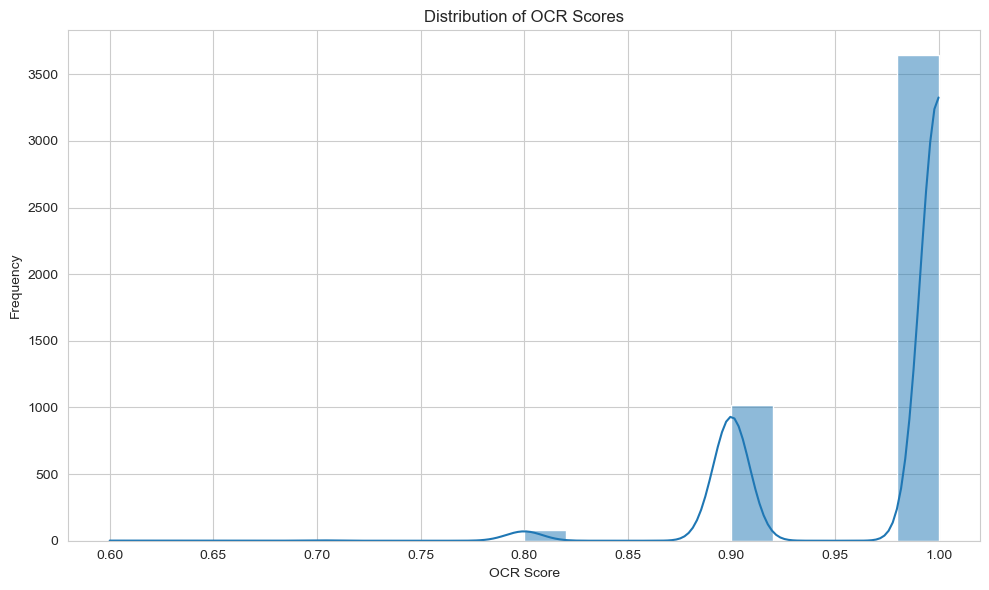

In [15]:
# 1. GENERAL DISTRIBUTION (HISTOGRAM)
# ---------------------------------------------

plt.figure(figsize=(10, 6))

sns.histplot(
    df['ocr_score'],
    bins=20,
    kde=True
)

plt.title('Distribution of OCR Scores')
plt.xlabel('OCR Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


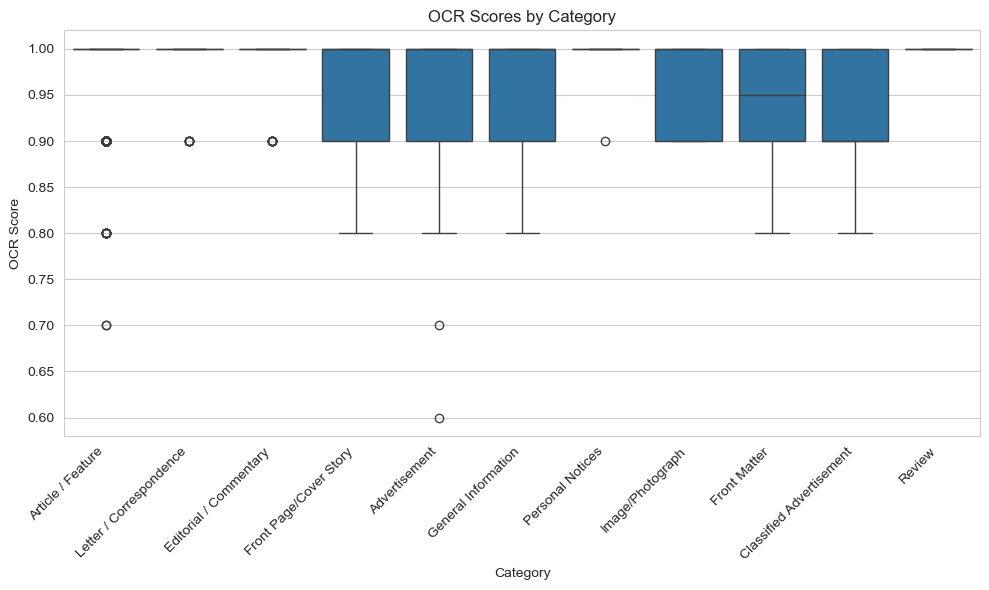

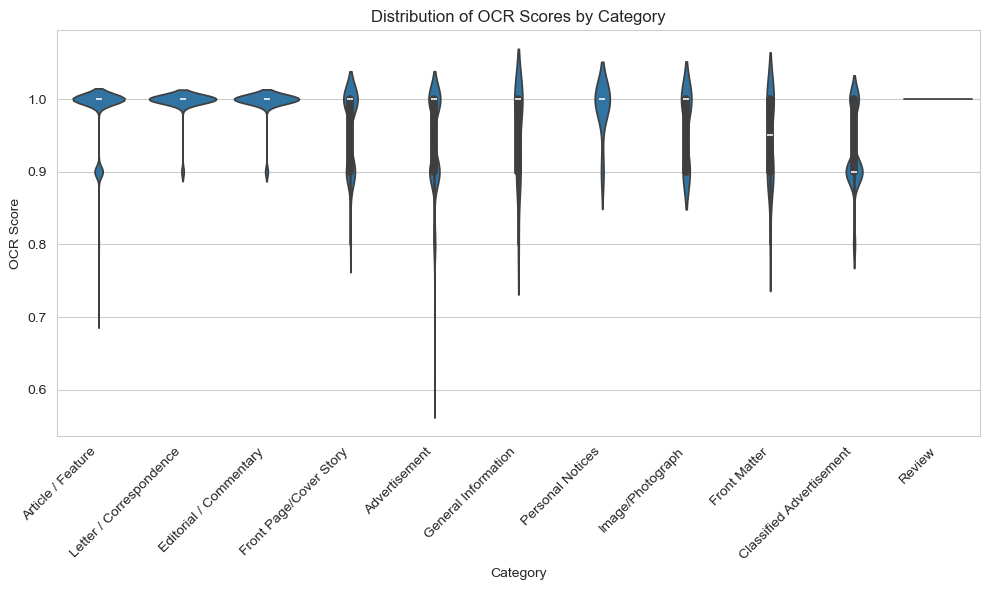

In [18]:
# 2. OCR DISTRIBUTION BY CATEGORY
# ---------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='category_clean',
    y='ocr_score'
)

plt.xticks(rotation=45, ha='right')
plt.title('OCR Scores by Category')
plt.xlabel('Category')
plt.ylabel('OCR Score')

plt.tight_layout()
plt.show()

# Optional violin plot

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='category_clean',
    y='ocr_score'
)

plt.xticks(rotation=45, ha='right')
plt.title('Distribution of OCR Scores by Category')
plt.xlabel('Category')
plt.ylabel('OCR Score')

plt.tight_layout()
plt.show()


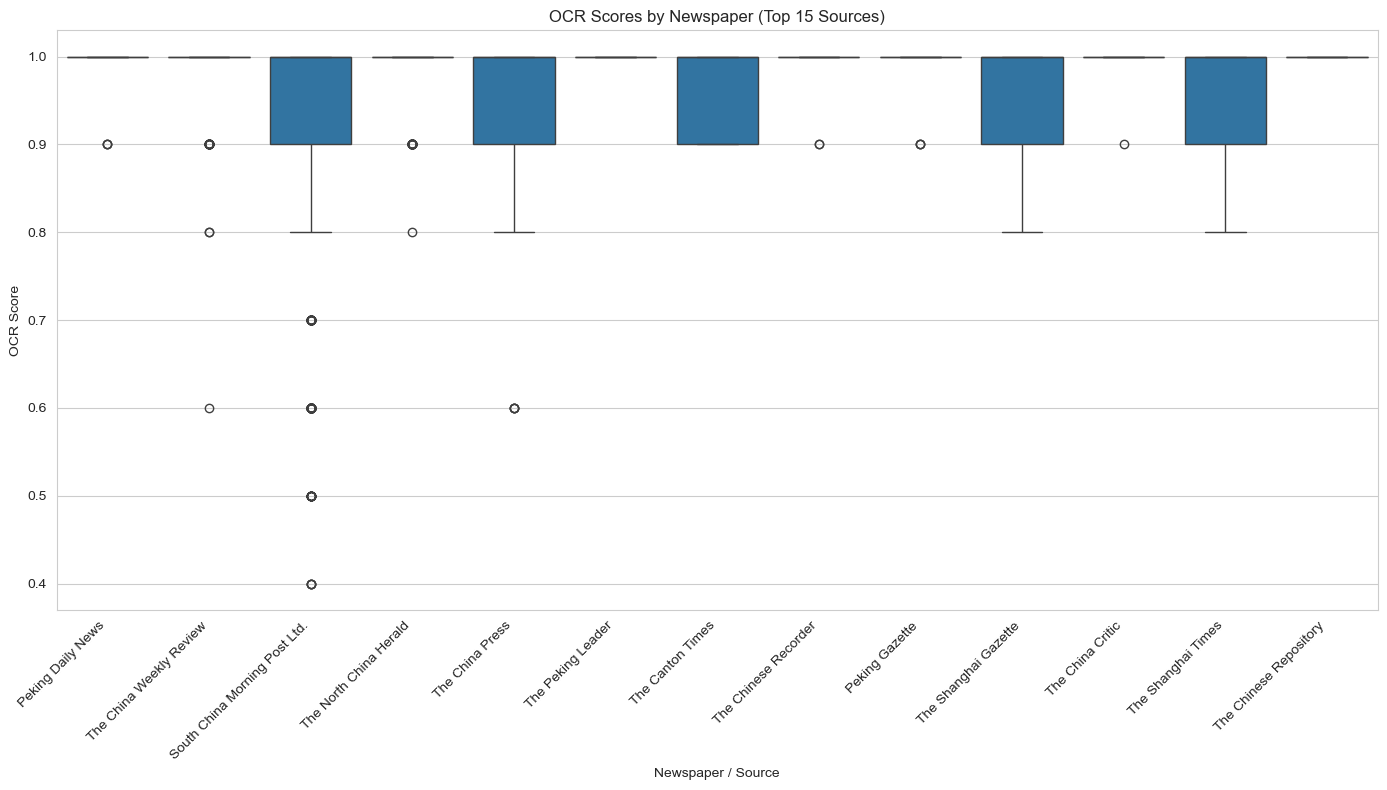

In [14]:
# 3. OCR DISTRIBUTION BY NEWSPAPER / SOURCE
# ---------------------------------------------
# Keep only top newspapers by number of articles
# to avoid overcrowding

TOP_N = 15

top_sources = (
    df['Source']
    .value_counts()
    .head(TOP_N)
    .index
)

subset_sources = df[df['Source'].isin(top_sources)]

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=subset_sources,
    x='Source',
    y='ocr_score'
)

plt.xticks(rotation=45, ha='right')
plt.title(f'OCR Scores by Newspaper (Top {TOP_N} Sources)')
plt.xlabel('Newspaper / Source')
plt.ylabel('OCR Score')

plt.tight_layout()
plt.show()

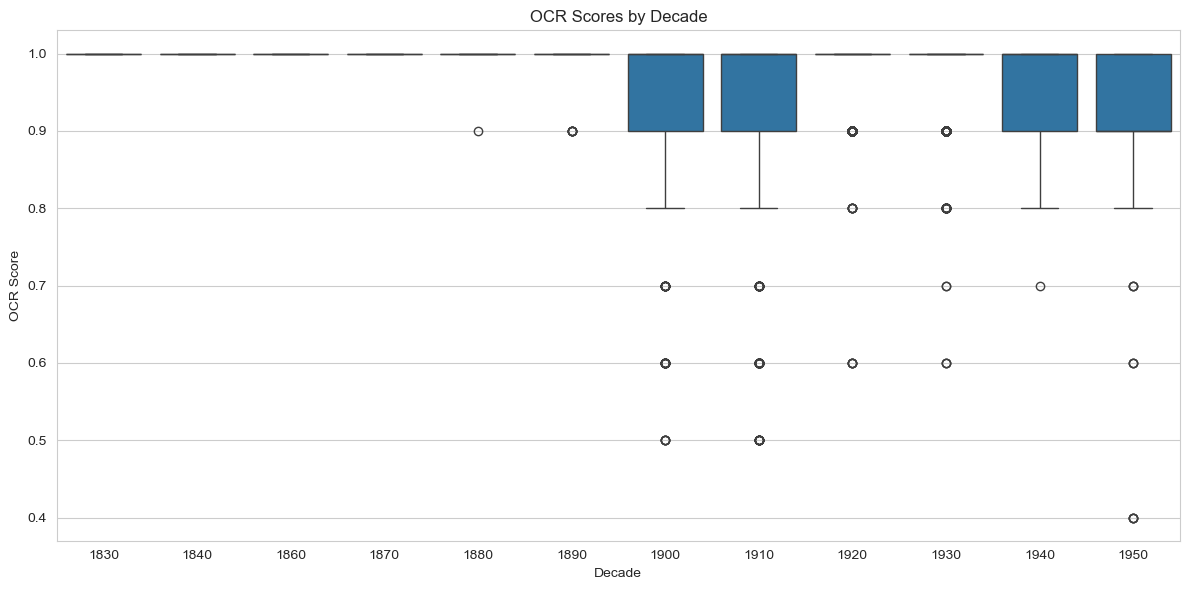

In [15]:
# 4. OCR SCORES OVER TIME (DECADES)
# ---------------------------------------------

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='decade',
    y='ocr_score'
)

plt.title('OCR Scores by Decade')
plt.xlabel('Decade')
plt.ylabel('OCR Score')

plt.tight_layout()
plt.show()


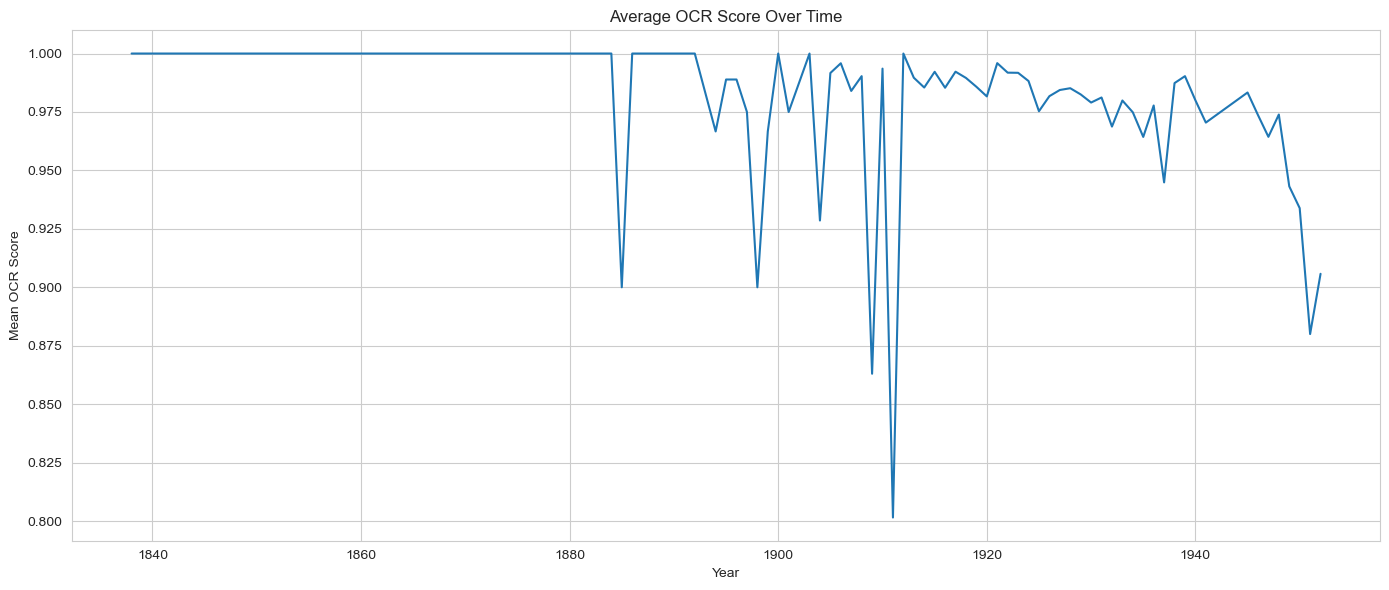

In [16]:
# 5. TEMPORAL TREND (MEAN OCR SCORE OVER TIME)
# ---------------------------------------------

mean_by_year = (
    df.groupby('year')['ocr_score']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=mean_by_year,
    x='year',
    y='ocr_score'
)

plt.title('Average OCR Score Over Time')
plt.xlabel('Year')
plt.ylabel('Mean OCR Score')

plt.tight_layout()
plt.show()

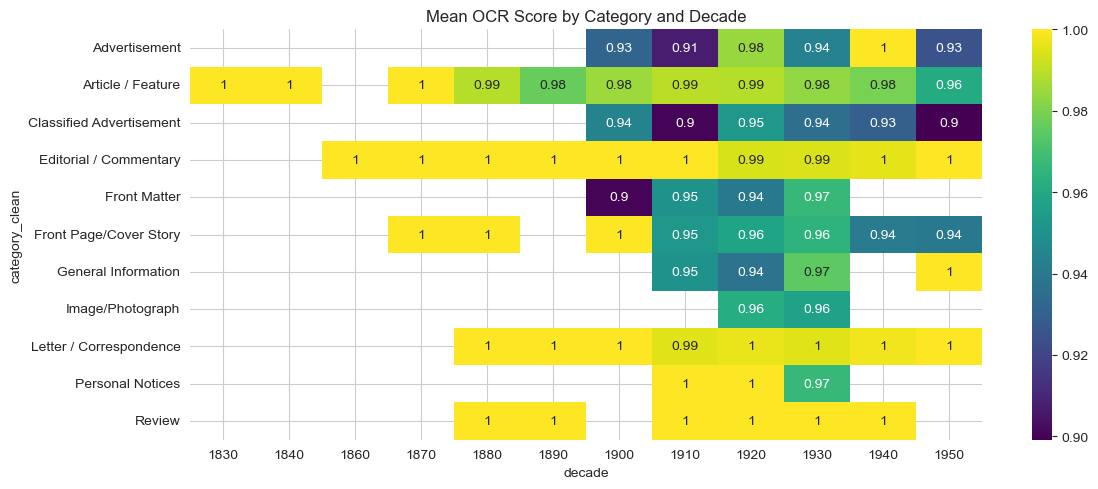

In [19]:
# 6. HEATMAP: CATEGORY x DECADE
# ---------------------------------------------

heatmap_data = (
    df.pivot_table(
        values='ocr_score',
        index='category_clean',
        columns='decade',
        aggfunc='mean'
    )
)

plt.figure(figsize=(12, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='viridis'
)

plt.title('Mean OCR Score by Category and Decade')

plt.tight_layout()
plt.show()


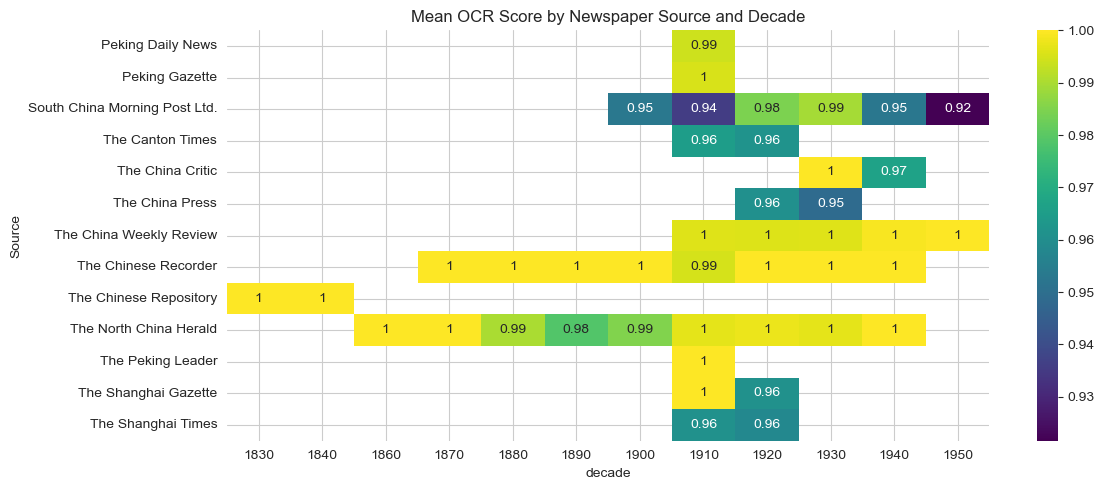

In [20]:
# 7. HEATMAP: DECADE x NEWSPAPER SOURCE
# ---------------------------------------------

heatmap_data = (
    df.pivot_table(
        values='ocr_score',
        index='Source',
        columns='decade',
        aggfunc='mean'
    )
)

plt.figure(figsize=(12, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='viridis'
)

plt.title('Mean OCR Score by Newspaper Source and Decade')

plt.tight_layout()
plt.show()


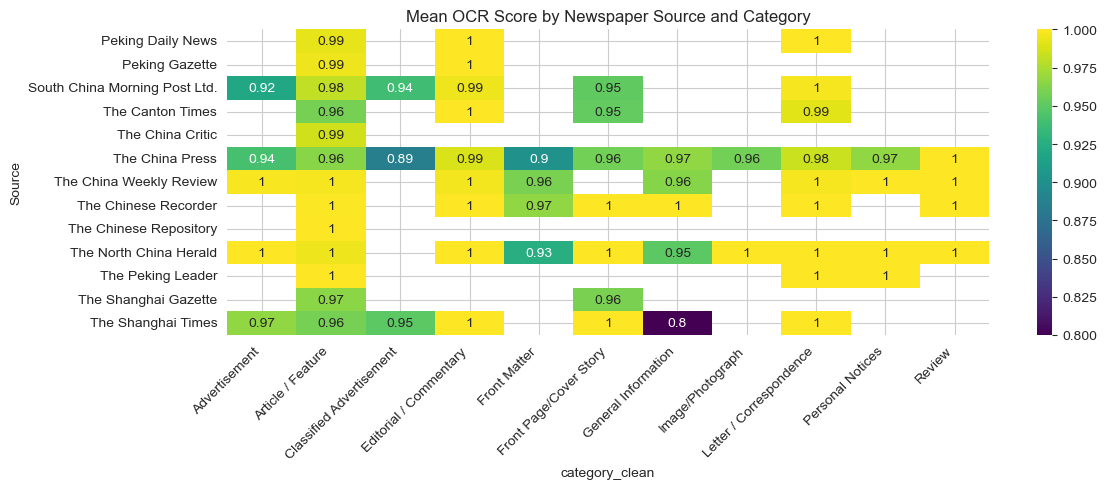

In [22]:
# 8. HEATMAP: CATEGORY x NEWSPAPER SOURCE
# ---------------------------------------------

heatmap_data = (
    df.pivot_table(
        values='ocr_score',
        index='Source',
        columns='category_clean',
        aggfunc='mean'
    )
)

plt.figure(figsize=(12, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='viridis'
)

plt.xticks(rotation=45, ha='right')
plt.title('Mean OCR Score by Newspaper Source and Category')

plt.tight_layout()
plt.show()


In [23]:
# Export summary tables (optional)
# ---------------------------------------------

category_stats.to_csv('ocr_stats_by_category.csv')
source_stats.to_csv('ocr_stats_by_source.csv')
decade_stats.to_csv('ocr_stats_by_decade.csv')

print("\nAnalysis complete.")
print("Summary tables exported as CSV files.")




Analysis complete.
Summary tables exported as CSV files.
